### Engineering multiple rolling features at once
Now that you've practiced some simple feature engineering, let's move on to something more complex. You'll calculate a collection of features for your time series data and visualize what they look like over time. This process resembles how many other time series models operate.

- Define a list consisting of four features you will calculate: the minimum, maximum, mean, and standard deviation (in that order).
- Using the rolling window (prices_perc_rolling) we defined for you, calculate the features from features_to_calculate.
- Plot the results over time, along with the original time series using the given code.

In [ ]:
# Define a rolling window with Pandas, excluding the right-most datapoint of the window
prices_perc_rolling = prices_perc.rolling(20, min_periods=5, closed='right')

# Define the features you'll calculate for each window
features_to_calculate = [np.min, np.max, np.mean, np.std]

# Calculate these features for your rolling window object
features = prices_perc_rolling.aggregate(features_to_calculate)

# Plot the results
ax = features.loc[:"2011-01"].plot()
prices_perc.loc[:"2011-01"].plot(ax=ax, color='k', alpha=.2, lw=3)
ax.legend(loc=(1.01, .6))
plt.show()

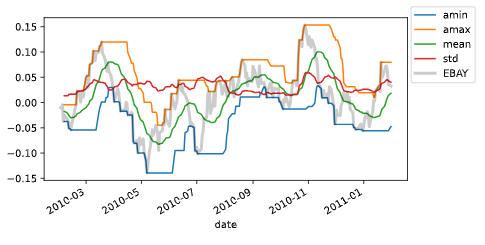

### Percentiles and partial functions
In this exercise, you'll practice how to pre-choose arguments of a function so that you can pre-configure how it runs. You'll use this to calculate several percentiles of your data using the same percentile() function in numpy.

- Import partial from functools.
- Use the partial() function to create several feature generators that calculate percentiles of your data using a list comprehension.
- Using the rolling window (prices_perc_rolling) we defined for you, calculate the quantiles using percentile_functions.
- Visualize the results using the code given to you.

In [ ]:
# Import partial from functools
from functools import partial
percentiles = [1, 10, 25, 50, 75, 90, 99]

# Use a list comprehension to create a partial function for each quantile
percentile_functions = [partial(np.percentile, q=percentile) for percentile in percentiles]

# Calculate each of these quantiles on the data using a rolling window
prices_perc_rolling = prices_perc.rolling(20, min_periods=5, closed='right')
features_percentiles = prices_perc_rolling.aggregate(percentile_functions)

# Plot a subset of the result
ax = features_percentiles.loc[:"2011-01"].plot(cmap=plt.cm.viridis)
ax.legend(percentiles, loc=(1.01, .5))
plt.show()

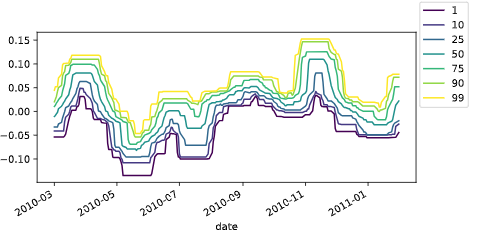

## Using "date" information
It's easy to think of timestamps as pure numbers, but don't forget they generally correspond to things that happen in the real world. That means there's often extra information encoded in the data such as "is it a weekday?" or "is it a holiday?". This information is often useful in predicting timeseries data.

In this exercise, you'll extract these date/time based features. A single time series has been loaded in a variable called prices.

- Calculate the day of the week, week number in a year, and month number in a year.
- Add each one as a column to the prices_perc DataFrame, under the names day_of_week, week_of_year and month_of_year, respectively.

In [ ]:
# Extract date features from the data, add them as columns
prices_perc['day_of_week'] = prices_perc.index.dayofweek
prices_perc['week_of_year'] = prices_perc.index.week
prices_perc['month_of_year'] = prices_perc.index.month

# Print prices_perc
print(prices_perc)
             EBAY  day_of_week  week_of_year  month_of_year
date                                                       
2014-01-02  0.018            3             1              1
2014-01-03  0.002            4             1              1
2014-01-06 -0.027            0             2              1
2014-01-07 -0.007            1             2              1
2014-01-08 -0.017            2             2              1
...           ...          ...           ...            ...
2015-12-24 -0.029            3            52             12
2015-12-28 -0.027            0            53             12
2015-12-29 -0.014            1            53             12
2015-12-30 -0.017            2            53             12
2015-12-31 -0.025            3            53             12

[504 rows x 4 columns]
